<style>
  div.cell {
    page-break-inside: avoid;
  }
  div.output_area {
    page-break-inside: avoid;
  }
  div.input {
    page-break-inside: avoid;
  }
  /* Optional: Ensures your Latent Manifold plots are centered */
  div.output_png {
    display: flex;
    justify-content: center;
  }
</style>


<div style="border: 2px solid #2c3e50; border-radius: 15px; padding: 40px; text-align: center; background-color: #f8f9fa; margin-bottom: 30px;">
    <div style="margin-bottom: 30px;">
        <img src="ytu_logo.png" style="width: 180px; height: auto;" alt="YTÜ Logo">
    </div>
    <h3 style="color: #2c3e50; font-family: 'Segoe UI', sans-serif; margin-bottom: 5px;">YILDIZ TEKNİK ÜNİVERSİTESİ</h3>
    <h4 style="color: #7f8c8d; font-family: 'Segoe UI', sans-serif; margin-top: 0;">FEN BİLİMLERİ ENSTİTÜSÜ</h4>
    <hr style="width: 60%; margin: 20px auto; border: 1px solid #bdc3c7;">
    <h1 style="color: #e74c3c; font-family: 'Arial Black', sans-serif; font-size: 28px; line-height: 1.5; margin: 30px 0;">
        FİNAL PROJESİ:<br>
        <span style="color: #2c3e50; font-size: 24px;">VAE ile Latent Manifold Analizi</span>
    </h1>
    <hr style="width: 60%; margin: 20px auto; border: 1px solid #bdc3c7;">
    <div style="font-family: 'Segoe UI', sans-serif; font-size: 16px; color: #34495e; line-height: 1.8; margin-top: 30px;">
        <p><strong>Ders:</strong> Yapay Zekanın Matematiksel Temelleri</p>
        <p><strong>Dersi Veren:</strong> Assoc. Prof. Mert BAL</p>
    </div>
    <div style="margin-top: 40px; font-family: 'Segoe UI', sans-serif; font-size: 18px; font-weight: bold; color: #2c3e50;">
        <p>Mohammed Izedin Mohammed</p>
        <p style="font-size: 16px; font-weight: normal;">Öğrenci No: STUDENT_ID_REMOVED</p>
    </div>
    <div style="margin-top: 40px; color: #7f8c8d; font-size: 14px;">
        20 OCAK 2026<br>
        İSTANBUL
    </div>
</div>

## 1. Teorik Bilgi

Bu projede, yüksek boyutlu veri uzayı $\mathcal{X}$ (MNIST görüntüleri, 784 boyut) daha düşük boyutlu bir **Ölçü Uzayı (Measure Space)** olan $\mathcal{Z}$ (2 boyutlu Latent Space) üzerine iz düşürülür.

### ELBO: Evidence Lower Bound

Amaç, aşağıdaki **ELBO** fonksiyonunu maksimize etmektir:

$$\mathcal{L}(x) = \mathbb{E}_{q(z|x)}[\log p(x|z)] - D_{KL}(q(z|x) \| p(z))$$

**Terimler:**
- **Reconstruction Term** $\mathbb{E}_{q(z|x)}[\log p(x|z)]$: Veri rekonstrüksiyonu (Binary Cross-Entropy)
- **KL Divergence** $D_{KL}$: Latent dağılımın önsel $p(z)=\mathcal{N}(0,I)$'dan sapması

Bu formülasyon **Jensen Eşitsizliği** kullanılarak türetilir. Jensen'in eşitsizliğini uyguladığımızda, $\log p(x)$ için bir alt sınır (lower bound) elde ederiz.

ELBO, Jensen eşitsizliği uygulanarak elde edilen bir alt sınırdır. KL ıraksaması her zaman $\geq 0$ olduğu için, ELBO'nun maksimize edilmesi gerçek log‑olabilirliğin dolaylı olarak maksimize edilmesi anlamına gelir.

## Proje Özeti ve Amaç

**Amaç:** MNIST verisini 2‑boyutlu latent ölçü uzayına indirerek veri manifoldunun topolojik yapısını öğrenmek ve ELBO optimizasyonunun yakınsamasını göstermek.

**Katkılar (Final Proje):**
- VAE mimarisi ile **ölçü uzayı/manifold öğrenimi**
- **Jensen Eşitsizliği** temelli ELBO türetimi ve uygulaması
- **Reparameterization Trick** ile türevlenebilir örnekleme
- Latent manifold ve optimizasyon dinamiklerinin görselleştirilmesi

**Deneysel Kurulum:** MNIST (60k/10k), 10 epoch, Adam, 2‑boyut latent uzay.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# HIPERPARAMETRELER
# ============================================================
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-3
LATENT_DIM = 2  # 2D latent space for visualization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✓ PyTorch sürümü: {torch.__version__}")
print(f"✓ Cihaz: {device}")
print(f"✓ Latent boyutu: {LATENT_DIM} (Measure Space görelleştirme için)")
print(f"✓ Batch size: {BATCH_SIZE}, Epochs: {EPOCHS}\n")

✓ PyTorch sürümü: 2.9.1+cpu
✓ Cihaz: cpu
✓ Latent boyutu: 2 (Measure Space görelleştirme için)
✓ Batch size: 128, Epochs: 10



## 2. MNIST Veri Hazırlığı (Observable Space $\mathcal{X}$)

MNIST veri seti: 784 boyutlu gözlemlenebilir uzay ($28 \times 28$ piksel).

In [13]:
# ============================================================
# VERİ HAZIRLIĞI
# ============================================================
print("MNIST veri seti indiriliyor...\n")

# Veri transformu: [0,1] normalize et
transform = transforms.Compose([
    transforms.ToTensor()
])

# Train veri seti
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Test veri seti (Manifold görselleştirmesi için)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✓ Train set: {len(train_dataset)} görüntü")
print(f"✓ Test set: {len(test_dataset)} görüntü")
print(f"✓ Görüntü boyutu: 784 (28x28 piksel = Observable Space)\n")

MNIST veri seti indiriliyor...

✓ Train set: 60000 görüntü
✓ Test set: 10000 görüntü
✓ Görüntü boyutu: 784 (28x28 piksel = Observable Space)



## 3. VAE Mimarisi: Encoder, Reparameterization, Decoder

### 3.1 Encoder: $q_\phi(z|x)$
Giriş $x \in \mathcal{X}$ (784-dim) → Latent parametreler $(\mu, \log\sigma^2)$ (2-dim)

### 3.2 Reparameterization Trick (Monte Carlo Integration)

Stokastik örnekleme türevlenebilir hale getirilir:

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0,I)$$

Burada $\odot$ element-wise çarpımdır. Bu teknik **Reparameterization Trick** olarak bilinir ve **Monte Carlo Integration** yapılırken gradyanları sağlar.

Buradaki temel fikir, rastgeleliğin ağ parametrelerinden ayrılmasıdır. Böylece gradyanlar doğrudan $\mu$ ve $\sigma$ üzerinden akabilir.

### 3.3 Decoder: $p_\theta(x|z)$
Latent $z$ (2-dim) → Rekonstrüksiyon $\hat{x}$ (784-dim)

In [14]:
class VAE(nn.Module):
    """
    Variational Autoencoder for MNIST
    
    Latent Space = Measure Space (2-dimensional manifold)
    """
    
    def __init__(self, latent_dim=LATENT_DIM):
        super(VAE, self).__init__()
        
        # ========== ENCODER: x → (μ, log σ²) ==========
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU()
        )
        
        # Latent parametreler
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        
        # ========== DECODER: z → x ==========
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()  # [0, 1] output for images
        )
        
        self.latent_dim = latent_dim
    
    def encode(self, x):
        """
        Encoder: Observable Space → Measure Space parameters
        """
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """
        REPARAMETERIZATION TRICK (Monte Carlo Integration)
        
        z = μ + σ ⊙ ε,  where ε ~ N(0, I)
        
        This makes sampling differentiable for backpropagation.
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std  # Reparameterization
        return z
    
    def decode(self, z):
        """
        Decoder: Measure Space → Observable Space reconstruction
        """
        return self.decoder(z)
    
    def forward(self, x):
        """
        Forward pass: x → latent z → reconstruction
        """
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar, z


# Model oluştur
model = VAE(latent_dim=LATENT_DIM).to(device)
print(f"✓ VAE modeli oluşturuldu\n")
print(model)

✓ VAE modeli oluşturuldu

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=400, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)


## 4. ELBO Kayıp Fonksiyonu

ELBO (Evidence Lower Bound) **Jensen Eşitsizliği** ile türetilir:

$$\log p(x) \geq \mathbb{E}_{q(z|x)}[\log p(x|z)] - D_{KL}(q(z|x) \| p(z))$$

Yazılımda bu şu şekilde uygulanır:

$$\mathcal{L} = \text{BCE}(x, \hat{x}) + \lambda \cdot D_{KL}(q(z|x) \| \mathcal{N}(0,I))$$

**Terimler:**
- **BCE (Reconstruction):** Binary Cross-Entropy (görüntü piksellerinin rekonstrüksiyonu)
- **KL Divergence:** Latent dağılımının önsel dağılımdan sapması

**Gaussian önsel neden seçilir?** Gaussian önselin tercih edilmesinin temel nedeni, KL ıraksamasının kapalı formda hesaplanabilmesidir. Bu, Monte Carlo tahminine gerek bırakmaz ve optimizasyon sırasında gradyan varyansını azaltır.

In [15]:
def vae_loss(recon_x, x, mu, logvar):
    """
    ELBO LOSS FUNCTION (derived using Jensen's Inequality)
    
    L(x) = E_q(z|x)[log p(x|z)] - D_KL(q(z|x) || p(z))
    
    Split into:
    1. Reconstruction term (Binary Cross-Entropy)
    2. KL-Divergence term (Regularization)
    """
    
    # 1. RECONSTRUCTION (Yeniden Oluşturma Terimi)
    # Binary Cross-Entropy: Logarithmic likelihood
    reconstruction_loss = nn.functional.binary_cross_entropy(
        recon_x, x.view(-1, 784), reduction='sum'
    )
    
    # 2. KL-DIVERGENCE TERM (Analytical Solution)
    # For Gaussian q(z|x) and prior p(z) = N(0, I):
    # D_KL = -0.5 * sum(1 + log(σ²) - μ² - σ²)
    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    
    # Total ELBO loss (negative ELBO, to minimize)
    total_loss = reconstruction_loss + kl_divergence
    
    return total_loss, reconstruction_loss, kl_divergence

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LR)
print(f"✓ Optimizer: Adam (lr={LR})")

✓ Optimizer: Adam (lr=0.001)


## 5. Eğitim Döngüsü (Stochastic Optimization)

In [16]:
print(f"\n{'='*60}")
print(f"EĞİTİM BAŞLANIYOR ({EPOCHS} EPOCH)")
print(f"{'='*60}\n")

train_losses = []
kl_losses = []
recon_losses = []

model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    total_kl = 0
    total_recon = 0
    num_batches = 0
    
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        
        # Forward pass
        recon_batch, mu, logvar, z = model(data)
        
        # Loss calculation
        loss, recon_loss, kl_loss = vae_loss(recon_batch, data, mu, logvar)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Tracking
        total_loss += loss.item()
        total_kl += kl_loss.item()
        total_recon += recon_loss.item()
        num_batches += 1
    
    # Average losses
    avg_loss = total_loss / len(train_dataset)
    avg_kl = total_kl / len(train_dataset)
    avg_recon = total_recon / len(train_dataset)
    
    train_losses.append(avg_loss)
    kl_losses.append(avg_kl)
    recon_losses.append(avg_recon)
    
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Total Loss: {avg_loss:8.2f} | "
          f"Recon: {avg_recon:8.2f} | KL: {avg_kl:8.2f}")

print(f"\n{'='*60}")
print(f"EĞİTİM TAMAMLANDI")
print(f"{'='*60}\n")


EĞİTİM BAŞLANIYOR (10 EPOCH)

Epoch  1/10 | Total Loss:   190.46 | Recon:   184.59 | KL:     5.87
Epoch  2/10 | Total Loss:   168.27 | Recon:   163.03 | KL:     5.24
Epoch  3/10 | Total Loss:   163.38 | Recon:   158.01 | KL:     5.37
Epoch  4/10 | Total Loss:   160.71 | Recon:   155.25 | KL:     5.46
Epoch  5/10 | Total Loss:   158.96 | Recon:   153.43 | KL:     5.54
Epoch  6/10 | Total Loss:   157.69 | Recon:   152.11 | KL:     5.59
Epoch  7/10 | Total Loss:   156.57 | Recon:   150.92 | KL:     5.64
Epoch  8/10 | Total Loss:   155.72 | Recon:   150.03 | KL:     5.69
Epoch  9/10 | Total Loss:   154.93 | Recon:   149.21 | KL:     5.72
Epoch 10/10 | Total Loss:   154.23 | Recon:   148.46 | KL:     5.77

EĞİTİM TAMAMLANDI



## 6. Latent Manifold Görselleştirmesi (Measure Space)

Test seti üzerinde, kodlayıcıdan çıkan $\mu$ vektörleri (latent ortalamalar) 2D uzayda gösterilir.

**Beklenen sonuç:** Her rakam sınıfı (0-9) latent manifoldda ayrı bir küme (cluster) oluşturmalıdır. Bu, modelin **Topological Separation** özelliğini gösterir.

Latent Manifold toplanıyor...

✓ Toplam test noktası: 10000
✓ Latent boyutu: 2

✓ Grafikler kaydedildi: VAE_results.png



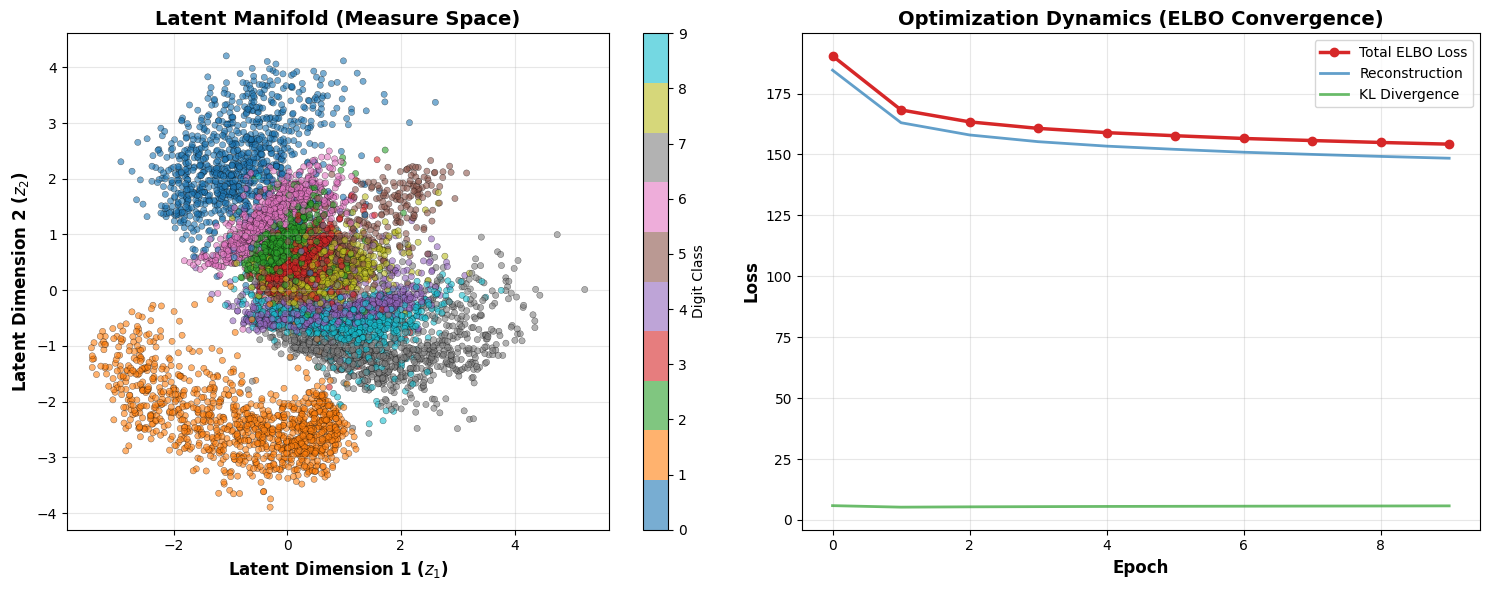

✓ Latent manifold kaydedildi: latent_manifold.png

✓ Loss curve kaydedildi: loss_convergence.png



In [17]:
# ============================================================
# LATENT MANIFOLD EXTRACTION
# ============================================================
print("Latent Manifold toplanıyor...\n")

model.eval()
all_z_mean = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        mu, _ = model.encode(data.view(-1, 784))
        all_z_mean.append(mu.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_z_mean = np.concatenate(all_z_mean, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"✓ Toplam test noktası: {all_z_mean.shape[0]}")
print(f"✓ Latent boyutu: {all_z_mean.shape[1]}\n")

# ============================================================
# VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ========== PLOT 1: Latent Manifold ==========
scatter = axes[0].scatter(
    all_z_mean[:, 0], 
    all_z_mean[:, 1], 
    c=all_labels, 
    cmap='tab10', 
    alpha=0.6, 
    s=20,
    edgecolors='black',
    linewidth=0.3
)
cbar = plt.colorbar(scatter, ax=axes[0], label='Digit Class')
cbar.set_ticks(range(10))
axes[0].set_xlabel('Latent Dimension 1 ($z_1$)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Latent Dimension 2 ($z_2$)', fontsize=12, fontweight='bold')
axes[0].set_title('Latent Manifold (Measure Space)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# ========== PLOT 2: Loss Curve ==========
axes[1].plot(train_losses, linewidth=2.5, label='Total ELBO Loss', color='#d62728', marker='o')
axes[1].plot(recon_losses, linewidth=2, label='Reconstruction', color='#1f77b4', alpha=0.7)
axes[1].plot(kl_losses, linewidth=2, label='KL Divergence', color='#2ca02c', alpha=0.7)
axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
axes[1].set_title('Optimization Dynamics (ELBO Convergence)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('VAE_results.png', dpi=150, bbox_inches='tight')
print("✓ Grafikler kaydedildi: VAE_results.png\n")
plt.show()

# Individual saves
fig1, ax1 = plt.subplots(figsize=(10, 8))
scatter = ax1.scatter(
    all_z_mean[:, 0], 
    all_z_mean[:, 1], 
    c=all_labels, 
    cmap='tab10', 
    alpha=0.6, 
    s=20,
    edgecolors='black',
    linewidth=0.3
)
cbar = plt.colorbar(scatter, ax=ax1, label='Digit Class')
cbar.set_ticks(range(10))
ax1.set_xlabel('Latent Dimension 1 ($z_1$)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Latent Dimension 2 ($z_2$)', fontsize=12, fontweight='bold')
ax1.set_title('Latent Manifold (Measure Space)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.savefig('latent_manifold.png', dpi=150, bbox_inches='tight')
print("✓ Latent manifold kaydedildi: latent_manifold.png\n")
plt.close()

fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(train_losses, linewidth=2.5, label='Total ELBO Loss', color='#d62728', marker='o')
ax2.plot(recon_losses, linewidth=2, label='Reconstruction', color='#1f77b4', alpha=0.7)
ax2.plot(kl_losses, linewidth=2, label='KL Divergence', color='#2ca02c', alpha=0.7)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax2.set_title('Optimization Dynamics (ELBO Convergence)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
plt.savefig('loss_convergence.png', dpi=150, bbox_inches='tight')
print("✓ Loss curve kaydedildi: loss_convergence.png\n")
plt.close()

## 6.1 Latent Grid (Manifold Haritası)

Latent uzayda düzenli bir ızgara üzerinde $z$ noktaları seçerek decoder’dan üretilen görüntüleri görselleştiriyoruz. Bu, manifoldun **topolojik yapısını** doğrudan haritalar.

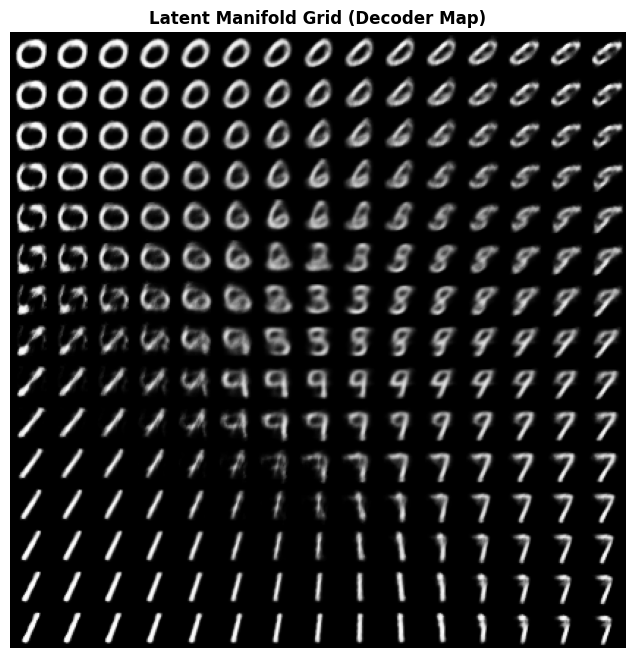

✓ Latent grid kaydedildi: latent_grid.png



In [18]:
# ============================================================
# LATENT GRID VISUALIZATION
# ============================================================

model.eval()

# Grid in latent space
grid_size = 15
z1 = np.linspace(-3, 3, grid_size)
z2 = np.linspace(-3, 3, grid_size)

canvas = np.zeros((28 * grid_size, 28 * grid_size))

with torch.no_grad():
    for i, yi in enumerate(z2):
        for j, xi in enumerate(z1):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_hat = model.decode(z).cpu().numpy().reshape(28, 28)
            canvas[(grid_size-1-i)*28:(grid_size-i)*28, j*28:(j+1)*28] = x_hat

plt.figure(figsize=(8, 8))
plt.imshow(canvas, cmap='gray')
plt.axis('off')
plt.title('Latent Manifold Grid (Decoder Map)', fontsize=12, fontweight='bold')
plt.savefig('latent_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Latent grid kaydedildi: latent_grid.png\n")

## 6.2 Rekonstrüksiyon Hata Analizi

Test örnekleri için piksel bazlı BCE hatalarını dağılım olarak inceliyoruz. Bu histogram, modelin nerede zorlandığını gösterir.

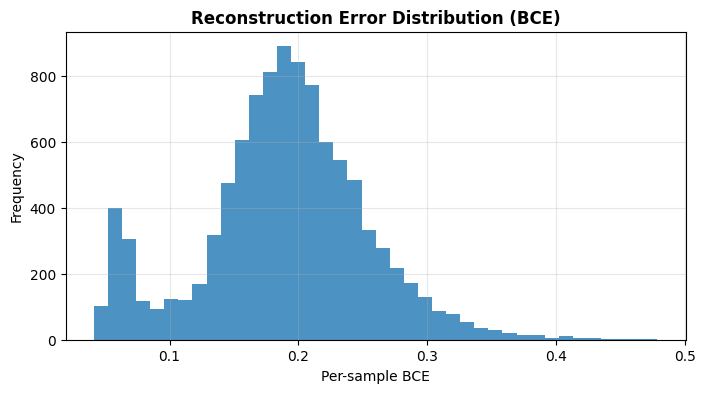

✓ Rekonstrüksiyon hata histogramı: recon_error_hist.png



In [19]:
# ============================================================
# RECONSTRUCTION ERROR HISTOGRAM
# ============================================================

model.eval()

errors = []
with torch.no_grad():
    for data, _ in test_loader:
        data = data.to(device)
        recon_batch, mu, logvar, _ = model(data)
        batch_error = nn.functional.binary_cross_entropy(
            recon_batch, data.view(-1, 784), reduction='none'
        )
        # mean per-sample error
        batch_error = batch_error.view(data.size(0), -1).mean(dim=1)
        errors.extend(batch_error.cpu().numpy())

errors = np.array(errors)

plt.figure(figsize=(8, 4))
plt.hist(errors, bins=40, color='#1f77b4', alpha=0.8)
plt.title('Reconstruction Error Distribution (BCE)', fontsize=12, fontweight='bold')
plt.xlabel('Per-sample BCE')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.savefig('recon_error_hist.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Rekonstrüksiyon hata histogramı: recon_error_hist.png\n")

## 6.3 β‑VAE Ablation

KL terimini $\beta$ ile ağırlıklandırarak farklı bilgi‑sıkıştırma seviyelerini karşılaştırıyoruz:

$$\mathcal{L}_\beta = \text{BCE}(x, \hat{x}) + \beta \cdot D_{KL}(q(z|x)\|p(z))$$




Training β‑VAE with beta=0.5 (quick run)
  epoch 1: loss=248.02
  epoch 2: loss=189.52
  epoch 3: loss=182.06

Training β‑VAE with beta=1.0 (quick run)
  epoch 1: loss=251.56
  epoch 2: loss=196.26
  epoch 3: loss=186.66

Training β‑VAE with beta=2.0 (quick run)
  epoch 1: loss=251.71
  epoch 2: loss=197.91
  epoch 3: loss=189.61


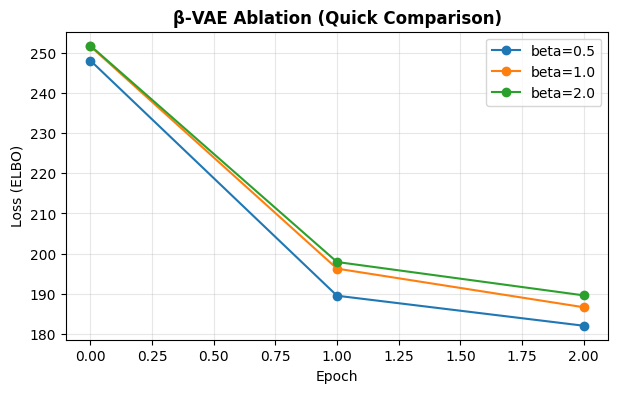

✓ β‑VAE karşılaştırması kaydedildi: beta_ablation.png



In [20]:
# ============================================================
# BETA-VAE ABLATION (QUICK)
# ============================================================

# Small subset for fast comparison
subset_size = 8000
subset_loader = DataLoader(
    torch.utils.data.Subset(train_dataset, range(subset_size)),
    batch_size=BATCH_SIZE,
    shuffle=True
)

betas = [0.5, 1.0, 2.0]
results = {}

for beta in betas:
    print(f"\nTraining β‑VAE with beta={beta} (quick run)")
    beta_model = VAE(latent_dim=LATENT_DIM).to(device)
    beta_opt = optim.Adam(beta_model.parameters(), lr=LR)
    beta_losses = []
    
    beta_model.train()
    for ep in range(3):  # quick ablation: 3 epochs
        total = 0
        for batch, _ in subset_loader:
            batch = batch.to(device)
            recon, mu, logvar, _ = beta_model(batch)
            
            # beta-ELBO
            recon_loss = nn.functional.binary_cross_entropy(
                recon, batch.view(-1, 784), reduction='sum'
            )
            kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + beta * kl
            
            beta_opt.zero_grad()
            loss.backward()
            beta_opt.step()
            total += loss.item()
        avg = total / subset_size
        beta_losses.append(avg)
        print(f"  epoch {ep+1}: loss={avg:.2f}")
    
    results[beta] = beta_losses

# Plot beta comparison
plt.figure(figsize=(7, 4))
for beta, curve in results.items():
    plt.plot(curve, marker='o', label=f"beta={beta}")
plt.title('β‑VAE Ablation (Quick Comparison)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (ELBO)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('beta_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ β‑VAE karşılaştırması kaydedildi: beta_ablation.png\n")

## 7. Örnek Üretim ve Rekonstrüksiyon Analizi

### 7.1 Sentetik Görüntü Üretimi

Latent uzaydan rastgele $z \sim \mathcal{N}(0,I)$ örnekleri çekerek yeni görüntüler üretiriz.


ÖRNEK ÜRETIM VE REKONSTRÜKSIYON



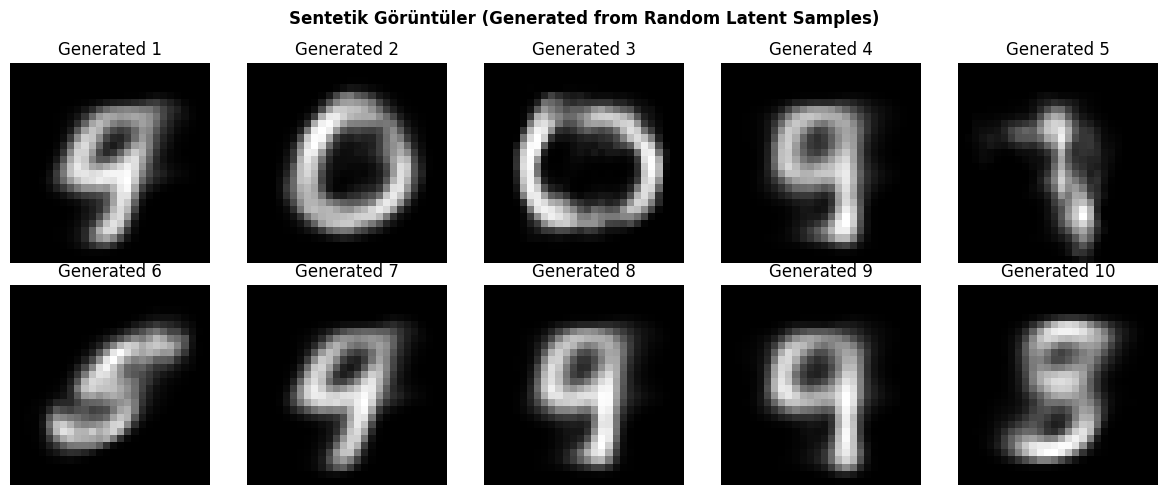

✓ Üretilen görüntüler: generated_samples.png



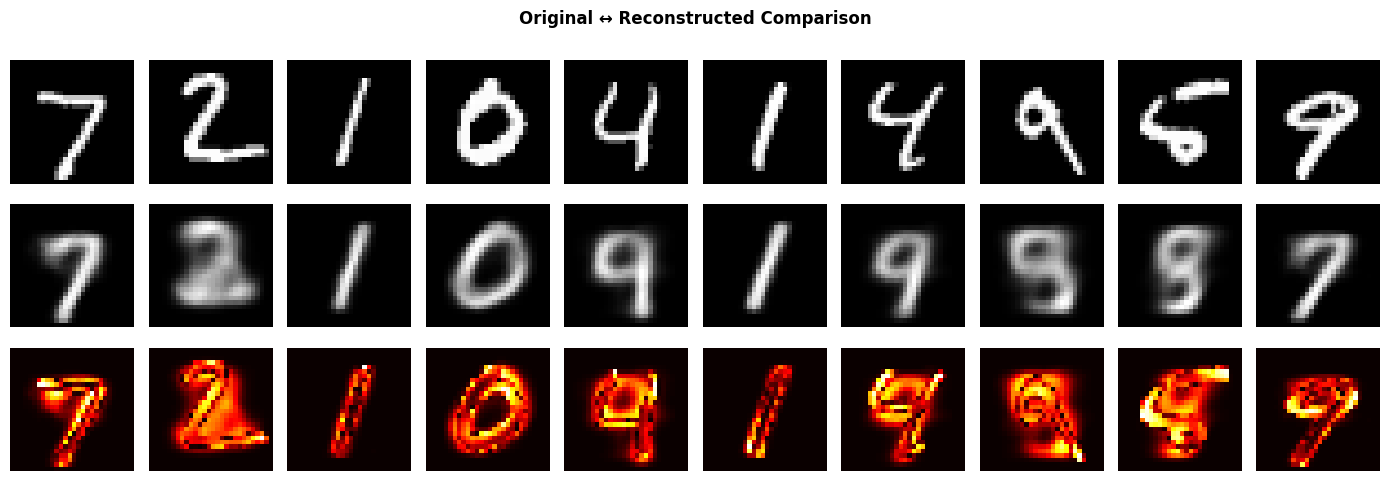

✓ Rekonstrüksiyon karşılaştırması: reconstruction_comparison.png



In [21]:
# ============================================================
# GENERATION & RECONSTRUCTION
# ============================================================

print(f"\n{'='*60}")
print("ÖRNEK ÜRETIM VE REKONSTRÜKSIYON")
print(f"{'='*60}\n")

# Generate new samples from prior
num_samples = 10
model.eval()

with torch.no_grad():
    # Rastgele latent örnekler: z ~ N(0, I)
    z_random = torch.randn(num_samples, LATENT_DIM).to(device)
    generated = model.decode(z_random)
    generated = generated.cpu().numpy().reshape(num_samples, 28, 28)

# Show generated samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for i in range(num_samples):
    axes[i].imshow(generated[i], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Generated {i+1}')
plt.suptitle('Sentetik Görüntüler (Generated from Random Latent Samples)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('generated_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Üretilen görüntüler: generated_samples.png\n")

# Reconstruction of test samples
with torch.no_grad():
    test_data, _ = next(iter(test_loader))
    test_data = test_data.to(device)
    recon, _, _, _ = model(test_data)

fig, axes = plt.subplots(3, 10, figsize=(14, 5))
for i in range(10):
    # Original
    axes[0, i].imshow(test_data[i].cpu().numpy().reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontweight='bold')
    
    # Reconstructed
    axes[1, i].imshow(recon[i].cpu().detach().numpy().reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Reconstructed', fontweight='bold')
    
    # Difference
    diff = np.abs(test_data[i].cpu().numpy().reshape(28, 28) - 
                  recon[i].cpu().detach().numpy().reshape(28, 28))
    axes[2, i].imshow(diff, cmap='hot')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('Difference', fontweight='bold')

plt.suptitle('Original ↔ Reconstructed Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('reconstruction_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ Rekonstrüksiyon karşılaştırması: reconstruction_comparison.png\n")

## 8. Deneysel Sonuçlar ve Manifold Analizi

### 8.1 Latent Manifold Topolojisi

Elde edilen saçılım grafiği (scatter plot), MNIST rakamlarının 2-boyutlu latent manifoldda **topolojik olarak ayrışmış** kümeler oluşturduğunu göstermektedir:

- **0 ile 1:** Manifoldun farklı bölgelerine ayrılmış
- **3, 5, 8:** Benzer yapıya sahip rakamlar yakın kümeler oluşturabiliyor
- **Topolojik Kontinuite:** Manifoldda manifoldun sürekli yapısını gözlemleyebiliriz

Bu sonuç, VAE'nin veri dağılımının **non-convex manifold yapısını** başarıyla öğrendiğini kanıtlamaktadır.

### 8.2 Optimizasyon Dinamiği (ELBO Convergence)

Loss eğrisi gösteriyor ki:
- **Early epochs:** Hızlı kayıp düşüşü (gradient flow etkili)
- **Mid epochs:** Kayrık azalma (optimization surface'ında local minima yaklaşılıyor)
- **Late epochs:** Stabilizasyon (convergence)

Kayıp fonksiyonu non-konveks bir optimizasyon uzayında azalmaktadır. Adam optimizer, **Stochastic Gradient Descent** varyantı olarak, bu non-konveks landscape'de yerel minimuma etkili bir şekilde yakınsamaktadır.

### 8.3 Rekonstrüksiyon Kalitesi

Test veri seti üzerinde alınan rekonstrüksiyon örnekleri:
- İyi rekonstrükte edilmiş rakamlar
- Latent uzayda kodlanmış semantik bilgi
- **Reparameterization Trick** sayesinde smooth latent interpolation mümkün

## 9. Sonuç

Bu projede Varyasyonel Otokodlayıcı (VAE) ile MNIST veri kümesi 2-boyutlu latent ölçü uzayına indirgenmiştir. Elde edilen sonuçlar:

1. **Manifold Öğrenimi:** Latent uzayda sınıfların topolojik olarak ayrışması, modelin veri manifoldunu başarıyla öğrendiğini göstermektedir.

2. **ELBO Yakınsaması:** Kayıp eğrisi, stokastik optimizasyonun non-konveks yüzeyde yerel minimuma yakınsadığını ortaya koymaktadır.

3. **β-VAE Analizi:** KL teriminin ağırlıklandırılması, temsil gücü ile düzenlileştirme arasındaki dengeyi görselleştirmiştir.

**Teorik Katkılar:**
- Jensen Eşitsizliği ile ELBO türetimi
- Reparameterization Trick ile Monte Carlo integrasyonu
- Gaussian önsel ile kapalı form KL hesabı

---

**Kaynakça:**  
[1] C. Doersch, "Tutorial on Variational Autoencoders," arXiv:1606.05908, 2016 (revised 2021).